# Load arrangement plans

`plot_load_plan` draws actual load definitions over the deck mesh. It accepts static case names, moving increment names, combinations, or `LoadCase` objects. A mapping overlays concurrent cases with their multipliers.

The positions below illustrate the plotting API. They are **not** an adverse-load search: use the load-case witness from your envelope or design check to plot a governing arrangement. No OpenSees analysis is required for drawing.

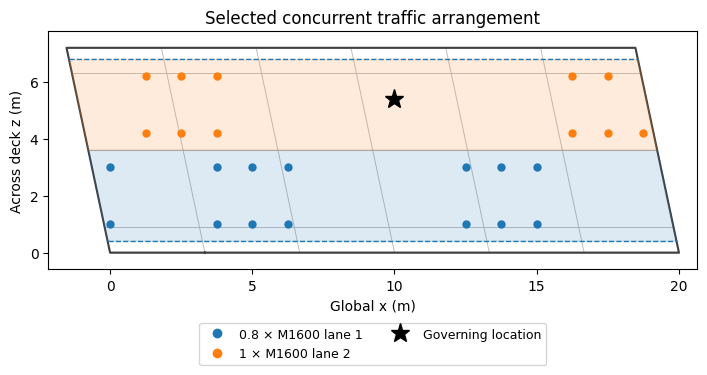

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import ospgrillage as og

bridge = og.create_grillage(
    bridge_name="Load arrangement example", long_dim=20, width=7.2,
    skew=12, num_long_grid=5, num_trans_grid=7, edge_beam_dist=.9,
    mesh_type="Oblique",
)
lanes = {}
for name, first_axle, centre, gap, factor in (
    ("M1600 lane 1", -2.5, 2.0, 6.25, .8),
    ("M1600 lane 2", -5., 5.2, 12.5, 1.),
):
    case = og.create_load_case(name=name)
    vehicle = og.create_load_model(model_type="M1600", gap=gap,
        origin=og.Point(first_axle, 0, centre)).create()
    case.add_load(vehicle, load_factor=1.3)
    # Full-span 6 kN/m lane UDL, with the same dynamic multiplier.
    corners = [(-30,centre-1.6),(50,centre-1.6),(50,centre+1.6),(-30,centre+1.6)]
    patch = og.create_load(**{f"point{i+1}": og.create_load_vertex(x=x,z=z,p=6000/3.2)
        for i,(x,z) in enumerate(corners)})
    case.add_load(patch, load_factor=1.3)
    lanes[case] = factor

ax = og.plot_load_plan(bridge, lanes, carriageway=(.4,6.8), highlight=(10,5.4),
    title="Selected concurrent traffic arrangement")
ax.set(xlabel="Global x (m)", ylabel="Across deck z (m)")
ax.figure.tight_layout()
plt.show()

Wheel markers and lane patches use a common colour for each case. Wheels and patches outside the skewed deck are clipped. Marker size and shading do not encode force or pressure magnitude. The star marks a supplied global location; the plotting helper does not decide which section governs.

For cases already registered on a model, pass their names. For moving loads, choose individual increment names, so mutually exclusive positions are not drawn together. Named combinations that contain several alternative increments from one moving load are rejected; select the intended increment explicitly.

/home/ccaprani/projects/ospgrillage-design/src/ospgrillage/utils.py:555: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root_func = fsolve(


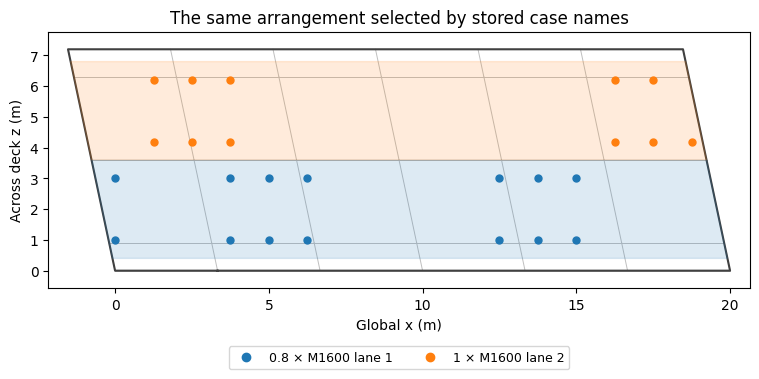

In [2]:
# Register the demonstration cases to show the equivalent name-based interface.
for case in lanes:
    bridge.add_load_case(case)
ax = og.plot_load_plan(bridge, {case.name: factor for case,factor in lanes.items()},
    title="The same arrangement selected by stored case names")
ax.set(xlabel="Global x (m)", ylabel="Across deck z (m)")
ax.figure.tight_layout()
plt.show()

The helper returns a Matplotlib `Axes`, accepts an existing `ax`, and defaults to `show=False`. For example, use `ax.figure.savefig("arrangement.png", bbox_inches="tight")` to export a design-review figure. Passing no `loadcase` draws the mesh alone. Point, compound, nodal, line and patch loads are supported; the model and its load objects are unchanged by plotting.